# 04 — Baseline Modeling

## CSIRO Image2Biomass Prediction

This notebook establishes baseline regression performance using the feature artifacts generated in the previous stages of the project.

The modeling pipeline evaluates multiple feature configurations and regression algorithms using the predefined cross-validation folds.

### Objectives

- Load and validate the final feature table generated by Notebook 03.
- Identify CNN, metadata, and combined feature configurations.
- Train baseline regression models using fold-based cross-validation.
- Generate out-of-fold (OOF) predictions for all biomass targets.
- Evaluate model performance using MAE, RMSE, and R².
- Compare the predictive contribution of image and metadata features.
- Compare Ridge Regression and Random Forest baseline models.
- Analyze model performance independently for each biomass target.
- Save evaluation metrics and OOF predictions for downstream experiments.
- Establish a reproducible performance benchmark for future deep learning and advanced modeling approaches.

### Baseline Models

The following regression models are evaluated:

1. **Ridge Regression**
   - Provides a simple linear baseline.
   - Uses L2 regularization to reduce model complexity.

2. **Random Forest Regression**
   - Provides a nonlinear ensemble baseline.
   - Captures complex relationships between CNN embeddings, metadata features, and biomass targets.

### Feature Configurations

Each baseline model is evaluated using:

1. **CNN Features**
   - 1280-dimensional EfficientNetB0 image embeddings.

2. **Metadata Features**
   - Fold-safe numerical and categorical metadata features.

3. **Combined Features**
   - CNN embeddings and metadata features concatenated into a single predictive feature matrix.

All experiments use the predefined 5-fold cross-validation assignments to ensure consistent and reproducible model comparison.

In [1]:
# ============================================================
# IMPORTS AND ENVIRONMENT SETUP
# ============================================================

import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PROJECT ROOT SETUP
# ============================================================

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


# ============================================================
# PROJECT IMPORTS
# ============================================================

from src.config import (
    FEATURE_TABLE_DIR,
    PREDICTIONS_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    RANDOM_SEED,
)

from src.modeling import (
    TARGET_COLUMNS,
    get_feature_columns,
    build_ridge_model,
    build_random_forest_model,
    calculate_regression_metrics,
    run_fold_cross_validation,
    summarize_cv_metrics,
    validate_oof_predictions,
)


# ============================================================
# DISPLAY CONFIGURATION
# ============================================================

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

np.random.seed(RANDOM_SEED)


# ============================================================
# ENVIRONMENT SUMMARY
# ============================================================

print("=" * 60)
print("BASELINE MODELING ENVIRONMENT")
print("=" * 60)

print(f"Project Root       : {PROJECT_ROOT}")
print(f"Feature Table Dir  : {FEATURE_TABLE_DIR}")
print(f"Predictions Dir    : {PREDICTIONS_DIR}")
print(f"Reports Dir        : {REPORTS_DIR}")
print(f"Figures Dir        : {FIGURES_DIR}")
print(f"Random Seed        : {RANDOM_SEED}")
print(f"Target Count       : {len(TARGET_COLUMNS)}")

print("=" * 60)

BASELINE MODELING ENVIRONMENT
Project Root       : e:\DATAVIDWAN\Image2Biomass
Feature Table Dir  : E:\DATAVIDWAN\Image2Biomass\data\processed\feature_tables
Predictions Dir    : E:\DATAVIDWAN\Image2Biomass\outputs\predictions
Reports Dir        : E:\DATAVIDWAN\Image2Biomass\outputs\reports
Figures Dir        : E:\DATAVIDWAN\Image2Biomass\outputs\figures
Random Seed        : 42
Target Count       : 5


In [3]:
# ============================================================
# LOAD FINAL FEATURE TABLE
# ============================================================

feature_table_path = (
    FEATURE_TABLE_DIR
    / "combined_features.csv"
)

if not feature_table_path.exists():
    raise FileNotFoundError(
        f"Feature table not found: {feature_table_path}"
    )

feature_table = pd.read_csv(
    feature_table_path
)


# ============================================================
# DATASET SUMMARY
# ============================================================

print("=" * 60)
print("FINAL FEATURE TABLE LOADED")
print("=" * 60)

print(f"File Path : {feature_table_path}")
print(f"Shape     : {feature_table.shape}")
print(f"Rows      : {len(feature_table)}")
print(f"Columns   : {feature_table.shape[1]}")

print("=" * 60)

display(feature_table.head())

FINAL FEATURE TABLE LOADED
File Path : E:\DATAVIDWAN\Image2Biomass\data\processed\feature_tables\combined_features.csv
Shape     : (357, 1309)
Rows      : 357
Columns   : 1309


,image_path,processed_image_path,fold,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,cnn_0000,cnn_0001,cnn_0002,cnn_0003,cnn_0004,cnn_0005,cnn_0006,cnn_0007,cnn_0008,cnn_0009,cnn_0010,cnn_0011,cnn_0012,cnn_0013,cnn_0014,cnn_0015,cnn_0016,cnn_0017,cnn_0018,cnn_0019,cnn_0020,cnn_0021,cnn_0022,cnn_0023,cnn_0024,cnn_0025,cnn_0026,cnn_0027,cnn_0028,cnn_0029,cnn_0030,cnn_0031,cnn_0032,cnn_0033,cnn_0034,cnn_0035,cnn_0036,cnn_0037,cnn_0038,cnn_0039,cnn_0040,cnn_0041,...,cnn_1251,cnn_1252,cnn_1253,cnn_1254,cnn_1255,cnn_1256,cnn_1257,cnn_1258,cnn_1259,cnn_1260,cnn_1261,cnn_1262,cnn_1263,cnn_1264,cnn_1265,cnn_1266,cnn_1267,cnn_1268,cnn_1269,cnn_1270,cnn_1271,cnn_1272,cnn_1273,cnn_1274,cnn_1275,cnn_1276,cnn_1277,cnn_1278,cnn_1279,Pre_GSHH_NDVI,Height_Ave_cm,State_NSW,State_Tas,State_Vic,State_WA,Species_Clover,Species_Fescue,Species_Fescue_CrumbWeed,Species_Lucerne,Species_Mixed,Species_Phalaris,Species_Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed,Species_Phalaris_Clover,Species_Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass,Species_Phalaris_Ryegrass_Clover,Species_Ryegrass,Species_Ryegrass_Clover,Species_SubcloverDalkeith,Species_SubcloverLosa,Species_WhiteClover
0,train/ID1011485656.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,3,0.0000,31.9984,16.2751,48.2735,16.2750,-0.129528,-0.114636,0.163882,-0.136905,-0.064059,-0.203835,-0.142202,0.163357,-0.172985,-0.051006,-0.235273,-0.179688,-0.227084,-0.040661,0.135909,-0.112759,-0.042580,-0.174920,-0.169060,-0.160379,-0.248347,-0.015741,0.212095,-0.234029,-0.162806,0.003940,-0.128425,-0.067290,-0.093142,-0.074564,-0.243456,-0.119395,-0.193312,-0.137048,-0.091544,-0.239962,0.073916,-0.151499,-0.100085,-0.181091,-0.134906,-0.173778,...,-0.138971,-0.056312,-0.205776,-0.206458,-0.210561,-0.171314,-0.087389,-0.225917,-0.131134,-0.169596,-0.248026,-0.058876,-0.182419,-0.159393,-0.185930,-0.227793,-0.068512,-0.035283,-0.179072,-0.090626,-0.059543,-0.076793,-0.146192,0.110080,0.037092,-0.029887,-0.242166,-0.119491,0.172999,-0.244040,-0.283154,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,train/ID1012260530.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,4,0.0000,0.0000,7.6000,7.6000,7.6000,0.230389,-0.185907,-0.076053,-0.122948,-0.145333,0.008207,-0.027867,-0.158804,0.091813,-0.168542,-0.106786,-0.086566,-0.068539,-0.162874,0.718639,1.172880,-0.081764,-0.177195,0.461883,-0.118039,1.129237,-0.026305,0.134631,-0.149939,-0.053560,-0.135072,-0.133320,-0.057693,0.209633,-0.121864,0.606456,-0.049010,0.425653,-0.046664,-0.061951,0.185264,1.886655,-0.103077,0.063352,-0.108158,-0.224585,-0.140063,...,0.326843,-0.218481,0.246931,-0.205143,-0.197096,-0.185131,-0.175212,-0.149967,0.189772,-0.125353,-0.199549,-0.125780,-0.129588,-0.074441,-0.138689,-0.072651,-0.039736,-0.218150,-0.142126,-0.195797,-0.158199,-0.097187,-0.071255,0.134333,-0.087876,-0.057759,0.074107,-0.135355,-0.121779,-0.634502,0.821992,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,train/ID1025234388.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,1,6.0500,0.0000,0.0000,6.0500,6.0500,0.078159,-0.212043,-0.066888,0.367200,0.150190,-0.177458,0.245461,-0.140621,-0.191462,-0.134596,0.232708,0.073322,-0.078465,-0.094043,0.007022,1.877365,-0.076874,-0.146888,-0.193715,-0.104048,0.192094,-0.016893,1.270971,-0.088034,-0.141130,-0.200278,-0.020111,0.229289,-0.025016,-0.158802,0.503918,-0.065161,-0.150302,-0.102301,-0.201720,-0.151562,1.921865,0.265348,0.062146,-0.179604,-0.136264,-0.186386,...,0.191955,-0.184963,0.356856,-0.001327,0.046062,-0.137182,0.171529,0.120441,0.501828,-0.098522,-0.147452,-0.084043,-0.083024,-0.123157,-0.184581,-0.134805,-0.093259,-0.170669,-0.048000,0.224073,-0.195609,-0.114934,-0.131965,0.814126,-0.138680,-0.034937,1.006905,0.106998,0.311039,-1.851811,-0.631375,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,train/ID1028611175.jpg,e:\DATAVIDWAN\Image2Biomass\data\processed\ima...,3,0.0000,30.9703

In [4]:
# ============================================================
# VALIDATE MODELING DATASET
# ============================================================

required_identifier_columns = [
    "image_path",
    "processed_image_path",
    "fold",
]

required_columns = (
    required_identifier_columns
    + TARGET_COLUMNS
)

missing_columns = [
    column
    for column in required_columns
    if column not in feature_table.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ============================================================
# BASIC VALIDATION STATISTICS
# ============================================================

duplicate_image_count = int(
    feature_table["image_path"].duplicated().sum()
)

missing_value_count = int(
    feature_table.isna().sum().sum()
)

numeric_columns = feature_table.select_dtypes(
    include=[np.number]
).columns

infinite_value_count = int(
    np.isinf(
        feature_table[numeric_columns].to_numpy()
    ).sum()
)

fold_counts = (
    feature_table["fold"]
    .value_counts()
    .sort_index()
)


# ============================================================
# VALIDATION OUTPUT
# ============================================================

print("=" * 60)
print("MODELING DATASET VALIDATION")
print("=" * 60)

print(f"Samples                 : {len(feature_table)}")
print(f"Total Columns           : {feature_table.shape[1]}")
print(f"Target Columns          : {len(TARGET_COLUMNS)}")
print(f"Duplicate Image Paths   : {duplicate_image_count}")
print(f"Missing Values          : {missing_value_count}")
print(f"Infinite Numeric Values : {infinite_value_count}")
print(f"Number of Folds         : {feature_table['fold'].nunique()}")

print("\nFold Distribution:")
print(fold_counts)

print("=" * 60)


# ============================================================
# FINAL VALIDATION CHECKS
# ============================================================

if duplicate_image_count > 0:
    raise ValueError(
        "Duplicate image paths detected."
    )

if missing_value_count > 0:
    raise ValueError(
        "Missing values detected in feature table."
    )

if infinite_value_count > 0:
    raise ValueError(
        "Infinite values detected in numeric columns."
    )

print("Modeling dataset validation passed successfully.")

MODELING DATASET VALIDATION
Samples                 : 357
Total Columns           : 1309
Target Columns          : 5
Duplicate Image Paths   : 0
Missing Values          : 0
Infinite Numeric Values : 0
Number of Folds         : 5

Fold Distribution:
fold
0    72
1    72
2    71
3    71
4    71
Name: count, dtype: int64
Modeling dataset validation passed successfully.


In [5]:
# ============================================================
# IDENTIFY FEATURE CONFIGURATIONS
# ============================================================

feature_sets = get_feature_columns(
    feature_table
)

cnn_features = feature_sets["cnn"]
metadata_features = feature_sets["metadata"]
combined_features = feature_sets["combined"]


# ============================================================
# FEATURE CONFIGURATION SUMMARY
# ============================================================

print("=" * 60)
print("FEATURE CONFIGURATION SUMMARY")
print("=" * 60)

print(f"CNN Features      : {len(cnn_features)}")
print(f"Metadata Features : {len(metadata_features)}")
print(f"Combined Features : {len(combined_features)}")

print("\nFeature Sets:")
for feature_set_name, feature_columns in feature_sets.items():
    print(
        f"{feature_set_name:<10} : "
        f"{len(feature_columns)} features"
    )

print("=" * 60)


# ============================================================
# FEATURE CONFIGURATION VALIDATION
# ============================================================

if len(cnn_features) != 1280:
    raise ValueError(
        f"Expected 1280 CNN features, "
        f"found {len(cnn_features)}."
    )

if len(metadata_features) != 21:
    raise ValueError(
        f"Expected 21 metadata features, "
        f"found {len(metadata_features)}."
    )

if len(combined_features) != 1301:
    raise ValueError(
        f"Expected 1301 combined features, "
        f"found {len(combined_features)}."
    )

if len(set(combined_features)) != len(combined_features):
    raise ValueError(
        "Duplicate columns detected in combined feature set."
    )

print("Feature configuration validation passed successfully.")

FEATURE CONFIGURATION SUMMARY
CNN Features      : 1280
Metadata Features : 21
Combined Features : 1301

Feature Sets:
cnn        : 1280 features
metadata   : 21 features
combined   : 1301 features
Feature configuration validation passed successfully.


In [6]:
# ============================================================
# DEFINE BASELINE EXPERIMENT CONFIGURATIONS
# ============================================================

experiment_configurations = [
    {
        "model_name": "Ridge",
        "feature_set_name": "cnn",
        "feature_columns": cnn_features,
        "model_builder": build_ridge_model,
    },
    {
        "model_name": "Ridge",
        "feature_set_name": "metadata",
        "feature_columns": metadata_features,
        "model_builder": build_ridge_model,
    },
    {
        "model_name": "Ridge",
        "feature_set_name": "combined",
        "feature_columns": combined_features,
        "model_builder": build_ridge_model,
    },
    {
        "model_name": "RandomForest",
        "feature_set_name": "cnn",
        "feature_columns": cnn_features,
        "model_builder": build_random_forest_model,
    },
    {
        "model_name": "RandomForest",
        "feature_set_name": "metadata",
        "feature_columns": metadata_features,
        "model_builder": build_random_forest_model,
    },
    {
        "model_name": "RandomForest",
        "feature_set_name": "combined",
        "feature_columns": combined_features,
        "model_builder": build_random_forest_model,
    },
]


# ============================================================
# EXPERIMENT SUMMARY
# ============================================================

experiment_summary = pd.DataFrame(
    [
        {
            "model": experiment["model_name"],
            "feature_set": experiment["feature_set_name"],
            "n_features": len(experiment["feature_columns"]),
        }
        for experiment in experiment_configurations
    ]
)


print("=" * 60)
print("BASELINE EXPERIMENT CONFIGURATIONS")
print("=" * 60)

print(f"Total Experiments : {len(experiment_configurations)}")
print(f"Models            : 2")
print(f"Feature Sets      : 3")
print(f"CV Folds          : {feature_table['fold'].nunique()}")
print(f"Total Model Fits  : {len(experiment_configurations) * feature_table['fold'].nunique()}")

print("=" * 60)

display(experiment_summary)

BASELINE EXPERIMENT CONFIGURATIONS
Total Experiments : 6
Models            : 2
Feature Sets      : 3
CV Folds          : 5
Total Model Fits  : 30


,model,feature_set,n_features
0,Ridge,cnn,1280
1,Ridge,metadata,21
2,Ridge,combined,1301
3,RandomForest,cnn,1280
4,RandomForest,metadata,21
5,RandomForest,combined,1301


In [7]:
# ============================================================
# RUN RIDGE BASELINE EXPERIMENTS
# ============================================================

ridge_oof_predictions = {}
ridge_fold_metrics = []

ridge_experiments = [
    experiment
    for experiment in experiment_configurations
    if experiment["model_name"] == "Ridge"
]


print("=" * 60)
print("RUNNING RIDGE BASELINE EXPERIMENTS")
print("=" * 60)


for experiment in ridge_experiments:

    feature_set_name = experiment["feature_set_name"]
    feature_columns = experiment["feature_columns"]
    model_builder = experiment["model_builder"]

    print(
        f"\nRunning Ridge with "
        f"{feature_set_name} features "
        f"({len(feature_columns)} features)..."
    )

    oof_predictions, fold_metrics = (
        run_fold_cross_validation(
            feature_table=feature_table,
            feature_columns=feature_columns,
            model_builder=model_builder,
            model_name="Ridge",
            feature_set_name=feature_set_name,
        )
    )

    ridge_oof_predictions[
        feature_set_name
    ] = oof_predictions

    ridge_fold_metrics.append(
        fold_metrics
    )

    print(
        f"Completed Ridge + "
        f"{feature_set_name}."
    )


# ============================================================
# COMBINE RIDGE METRICS
# ============================================================

ridge_fold_metrics = pd.concat(
    ridge_fold_metrics,
    ignore_index=True,
)


print("\n" + "=" * 60)
print("RIDGE BASELINE EXPERIMENTS COMPLETED")
print("=" * 60)

print(
    f"OOF Prediction Sets : "
    f"{len(ridge_oof_predictions)}"
)

print(
    f"Fold Metric Rows    : "
    f"{len(ridge_fold_metrics)}"
)

print("=" * 60)

RUNNING RIDGE BASELINE EXPERIMENTS

Running Ridge with cnn features (1280 features)...
Completed Ridge + cnn.

Running Ridge with metadata features (21 features)...
Completed Ridge + metadata.

Running Ridge with combined features (1301 features)...
Completed Ridge + combined.

RIDGE BASELINE EXPERIMENTS COMPLETED
OOF Prediction Sets : 3
Fold Metric Rows    : 75


In [8]:
# ============================================================
# VALIDATE RIDGE OOF PREDICTIONS
# ============================================================

ridge_prediction_validation = {}


print("=" * 60)
print("RIDGE OOF PREDICTION VALIDATION")
print("=" * 60)


for feature_set_name, predictions in ridge_oof_predictions.items():

    validation_results = validate_oof_predictions(
        predictions=predictions,
        expected_samples=len(feature_table),
    )

    ridge_prediction_validation[
        feature_set_name
    ] = validation_results

    print(f"\nFeature Set : {feature_set_name}")
    print(f"Shape       : {predictions.shape}")
    print(f"NaN Count   : {validation_results['nan_count']}")
    print(f"Inf Count   : {validation_results['inf_count']}")
    print(
        f"Minimum     : "
        f"{validation_results['prediction_min']:.4f}"
    )
    print(
        f"Maximum     : "
        f"{validation_results['prediction_max']:.4f}"
    )


print("\n" + "=" * 60)
print("All Ridge OOF predictions validated successfully.")
print("=" * 60)

RIDGE OOF PREDICTION VALIDATION

Feature Set : cnn
Shape       : (357, 5)
NaN Count   : 0
Inf Count   : 0
Minimum     : -40.4575
Maximum     : 120.2435

Feature Set : metadata
Shape       : (357, 5)
NaN Count   : 0
Inf Count   : 0
Minimum     : -17.8795
Maximum     : 141.6520

Feature Set : combined
Shape       : (357, 5)
NaN Count   : 0
Inf Count   : 0
Minimum     : -42.0368
Maximum     : 143.4619

All Ridge OOF predictions validated successfully.


In [9]:
# ============================================================
# SUMMARIZE RIDGE CROSS-VALIDATION PERFORMANCE
# ============================================================

ridge_cv_summary = summarize_cv_metrics(
    ridge_fold_metrics
)


# ============================================================
# DISPLAY SUMMARY
# ============================================================

print("=" * 60)
print("RIDGE CROSS-VALIDATION PERFORMANCE SUMMARY")
print("=" * 60)

print(f"Fold Metric Rows : {len(ridge_fold_metrics)}")
print(f"Summary Rows     : {len(ridge_cv_summary)}")

print("=" * 60)

display(
    ridge_cv_summary.sort_values(
        by=[
            "feature_set",
            "target",
        ]
    ).reset_index(drop=True)
)

RIDGE CROSS-VALIDATION PERFORMANCE SUMMARY
Fold Metric Rows : 75
Summary Rows     : 15


,model,feature_set,target,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Ridge,cnn,Dry_Clover_g,5.513821,1.008316,8.225223,1.973612,0.453355,0.379571
1,Ridge,cnn,Dry_Dead_g,8.836766,0.323449,11.629821,0.773042,0.095587,0.146298
2,Ridge,cnn,Dry_Green_g,12.812702,0.773459,17.825371,2.159879,0.503709,0.063665
3,Ridge,cnn,Dry_Total_g,15.529385,0.559582,20.823060,2.213029,0.437368,0.067212
4,Ridge,cnn,GDM_g,12.425408,1.015845,17.260125,2.183710,0.517212,0.063440
5,Ridge,combined,Dry_Clover_g,5.059269,0.769850,7.248990,1.436191,0.590408,0.244601
6,Ridge,combined,Dry_Dead_g,8.381336,0.403075,11.083677,0.370143,0.178994,0.114278
7,Ridge,combined,Dry_Green_g,9.110766,0.488522,12.804873,0.734524,0.741489,0.034037
8,Ridge,combined,Dry_Total_g,13.883819,0.579611,18.067323,0.884568,0.574110,0.044466
9,Ridge,combined,GDM_g,10.049236,0.690634,14.030224,1.378836,0.677033,0.062775


In [10]:
# ============================================================
# RUN RANDOM FOREST BASELINE EXPERIMENTS
# ============================================================

rf_oof_predictions = {}
rf_fold_metrics = []

rf_experiments = [
    experiment
    for experiment in experiment_configurations
    if experiment["model_name"] == "RandomForest"
]


print("=" * 60)
print("RUNNING RANDOM FOREST BASELINE EXPERIMENTS")
print("=" * 60)


for experiment in rf_experiments:

    feature_set_name = experiment["feature_set_name"]
    feature_columns = experiment["feature_columns"]
    model_builder = experiment["model_builder"]

    print(
        f"\nRunning Random Forest with "
        f"{feature_set_name} features "
        f"({len(feature_columns)} features)..."
    )

    oof_predictions, fold_metrics = (
        run_fold_cross_validation(
            feature_table=feature_table,
            feature_columns=feature_columns,
            model_builder=model_builder,
            model_name="RandomForest",
            feature_set_name=feature_set_name,
        )
    )

    rf_oof_predictions[
        feature_set_name
    ] = oof_predictions

    rf_fold_metrics.append(
        fold_metrics
    )

    print(
        f"Completed Random Forest + "
        f"{feature_set_name}."
    )


# ============================================================
# COMBINE RANDOM FOREST METRICS
# ============================================================

rf_fold_metrics = pd.concat(
    rf_fold_metrics,
    ignore_index=True,
)


print("\n" + "=" * 60)
print("RANDOM FOREST BASELINE EXPERIMENTS COMPLETED")
print("=" * 60)

print(
    f"OOF Prediction Sets : "
    f"{len(rf_oof_predictions)}"
)

print(
    f"Fold Metric Rows    : "
    f"{len(rf_fold_metrics)}"
)

print("=" * 60)

RUNNING RANDOM FOREST BASELINE EXPERIMENTS

Running Random Forest with cnn features (1280 features)...
Completed Random Forest + cnn.

Running Random Forest with metadata features (21 features)...
Completed Random Forest + metadata.

Running Random Forest with combined features (1301 features)...
Completed Random Forest + combined.

RANDOM FOREST BASELINE EXPERIMENTS COMPLETED
OOF Prediction Sets : 3
Fold Metric Rows    : 75


In [11]:
# ============================================================
# VALIDATE RANDOM FOREST OOF PREDICTIONS
# ============================================================

rf_prediction_validation = {}


print("=" * 60)
print("RANDOM FOREST OOF PREDICTION VALIDATION")
print("=" * 60)


for feature_set_name, predictions in rf_oof_predictions.items():

    validation_results = validate_oof_predictions(
        predictions=predictions,
        expected_samples=len(feature_table),
    )

    rf_prediction_validation[
        feature_set_name
    ] = validation_results

    print(f"\nFeature Set : {feature_set_name}")
    print(f"Shape       : {predictions.shape}")
    print(f"NaN Count   : {validation_results['nan_count']}")
    print(f"Inf Count   : {validation_results['inf_count']}")
    print(
        f"Minimum     : "
        f"{validation_results['prediction_min']:.4f}"
    )
    print(
        f"Maximum     : "
        f"{validation_results['prediction_max']:.4f}"
    )


print("\n" + "=" * 60)
print("All Random Forest OOF predictions validated successfully.")
print("=" * 60)

RANDOM FOREST OOF PREDICTION VALIDATION

Feature Set : cnn
Shape       : (357, 5)
NaN Count   : 0
Inf Count   : 0
Minimum     : 1.9611
Maximum     : 99.7003

Feature Set : metadata
Shape       : (357, 5)
NaN Count   : 0
Inf Count   : 0
Minimum     : 0.0000
Maximum     : 129.2235

Feature Set : combined
Shape       : (357, 5)
NaN Count   : 0
Inf Count   : 0
Minimum     : 0.9162
Maximum     : 105.7175

All Random Forest OOF predictions validated successfully.


In [12]:
# ============================================================
# SUMMARIZE RANDOM FOREST CROSS-VALIDATION PERFORMANCE
# ============================================================

rf_cv_summary = summarize_cv_metrics(
    rf_fold_metrics
)


# ============================================================
# DISPLAY SUMMARY
# ============================================================

print("=" * 60)
print("RANDOM FOREST CROSS-VALIDATION PERFORMANCE SUMMARY")
print("=" * 60)

print(f"Fold Metric Rows : {len(rf_fold_metrics)}")
print(f"Summary Rows     : {len(rf_cv_summary)}")

print("=" * 60)

display(
    rf_cv_summary.sort_values(
        by=[
            "feature_set",
            "target",
        ]
    ).reset_index(drop=True)
)

RANDOM FOREST CROSS-VALIDATION PERFORMANCE SUMMARY
Fold Metric Rows : 75
Summary Rows     : 15


,model,feature_set,target,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,RandomForest,cnn,Dry_Clover_g,6.587769,0.636887,10.015664,0.903965,0.289240,0.087047
1,RandomForest,cnn,Dry_Dead_g,7.484240,0.377397,10.163201,1.037529,0.314880,0.097192
2,RandomForest,cnn,Dry_Green_g,11.843149,1.315202,18.108122,2.516446,0.489579,0.066566
3,RandomForest,cnn,Dry_Total_g,14.995257,0.716505,20.256846,2.559291,0.469137,0.066471
4,RandomForest,cnn,GDM_g,12.357587,0.947758,17.865842,2.431714,0.483135,0.074305
5,RandomForest,combined,Dry_Clover_g,5.818611,0.819628,9.019317,1.257763,0.422499,0.115633
6,RandomForest,combined,Dry_Dead_g,7.078242,0.181383,9.891542,0.979178,0.351958,0.080365
7,RandomForest,combined,Dry_Green_g,8.911017,0.791453,13.615037,2.001139,0.708803,0.060724
8,RandomForest,combined,Dry_Total_g,12.700961,1.164281,16.904579,2.625483,0.631013,0.057061
9,RandomForest,combined,GDM_g,10.169983,1.007554,14.280963,2.234382,0.668286,0.069575


In [13]:
# ============================================================
# COMBINE ALL BASELINE RESULTS
# ============================================================

all_fold_metrics = pd.concat(
    [
        ridge_fold_metrics,
        rf_fold_metrics,
    ],
    ignore_index=True,
)

all_cv_summary = summarize_cv_metrics(
    all_fold_metrics
)


# ============================================================
# VALIDATE COMBINED RESULTS
# ============================================================

expected_fold_metric_rows = (
    len(experiment_configurations)
    * feature_table["fold"].nunique()
    * len(TARGET_COLUMNS)
)

expected_summary_rows = (
    len(experiment_configurations)
    * len(TARGET_COLUMNS)
)


if len(all_fold_metrics) != expected_fold_metric_rows:
    raise ValueError(
        f"Expected {expected_fold_metric_rows} fold metric rows, "
        f"found {len(all_fold_metrics)}."
    )

if len(all_cv_summary) != expected_summary_rows:
    raise ValueError(
        f"Expected {expected_summary_rows} summary rows, "
        f"found {len(all_cv_summary)}."
    )


# ============================================================
# DISPLAY COMBINED RESULTS SUMMARY
# ============================================================

print("=" * 60)
print("COMBINED BASELINE RESULTS")
print("=" * 60)

print(f"Models           : {all_fold_metrics['model'].nunique()}")
print(f"Feature Sets     : {all_fold_metrics['feature_set'].nunique()}")
print(f"Experiments      : {len(experiment_configurations)}")
print(f"Fold Metric Rows : {len(all_fold_metrics)}")
print(f"Summary Rows     : {len(all_cv_summary)}")

print("=" * 60)

display(
    all_cv_summary.sort_values(
        by=[
            "target",
            "RMSE_mean",
        ]
    ).reset_index(drop=True)
)

COMBINED BASELINE RESULTS
Models           : 2
Feature Sets     : 3
Experiments      : 6
Fold Metric Rows : 150
Summary Rows     : 30


,model,feature_set,target,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,RandomForest,metadata,Dry_Clover_g,3.839744,0.685794,6.605374,1.235277,0.691467,0.081517
1,Ridge,combined,Dry_Clover_g,5.059269,0.769850,7.248990,1.436191,0.590408,0.244601
2,Ridge,cnn,Dry_Clover_g,5.513821,1.008316,8.225223,1.973612,0.453355,0.379571
3,Ridge,metadata,Dry_Clover_g,5.554165,0.553719,8.297992,1.118290,0.513804,0.079126
4,RandomForest,combined,Dry_Clover_g,5.818611,0.819628,9.019317,1.257763,0.422499,0.115633
5,RandomForest,cnn,Dry_Clover_g,6.587769,0.636887,10.015664,0.903965,0.289240,0.087047
6,RandomForest,combined,Dry_Dead_g,7.078242,0.181383,9.891542,0.979178,0.351958,0.080365
7,RandomForest,metadata,Dry_Dead_g,6.731192,0.870358,9.996875,1.034031,0.326331,0.164476
8,RandomForest,cnn,Dry_Dead_g,7.484240,0.377397,10.163201,1.037529,0.314880,0.097192
9,Ridge,metadata,Dry_Dead_g,7.339125,0.301335,10.468251,0.757676,0.269989,0.108917


In [14]:
# ============================================================
# CREATE OVERALL BASELINE MODEL RANKING
# ============================================================

overall_model_ranking = (
    all_cv_summary
    .groupby(
        [
            "model",
            "feature_set",
        ],
        as_index=False,
    )
    .agg(
        Mean_MAE=("MAE_mean", "mean"),
        Mean_RMSE=("RMSE_mean", "mean"),
        Mean_R2=("R2_mean", "mean"),
    )
    .sort_values(
        by="Mean_RMSE",
        ascending=True,
    )
    .reset_index(drop=True)
)

overall_model_ranking.insert(
    0,
    "rank",
    np.arange(
        1,
        len(overall_model_ranking) + 1,
    ),
)


# ============================================================
# DISPLAY OVERALL RANKING
# ============================================================

print("=" * 60)
print("OVERALL BASELINE MODEL RANKING")
print("=" * 60)

display(overall_model_ranking)

print("=" * 60)

best_experiment = overall_model_ranking.iloc[0]

print(
    f"Best Model       : "
    f"{best_experiment['model']}"
)

print(
    f"Best Feature Set : "
    f"{best_experiment['feature_set']}"
)

print(
    f"Mean MAE         : "
    f"{best_experiment['Mean_MAE']:.4f}"
)

print(
    f"Mean RMSE        : "
    f"{best_experiment['Mean_RMSE']:.4f}"
)

print(
    f"Mean R2          : "
    f"{best_experiment['Mean_R2']:.4f}"
)

print("=" * 60)

OVERALL BASELINE MODEL RANKING


,rank,model,feature_set,Mean_MAE,Mean_RMSE,Mean_R2
0,1,RandomForest,metadata,7.076655,10.282782,0.681503
1,2,Ridge,metadata,8.153635,11.443891,0.609753
2,3,Ridge,combined,9.296885,12.647017,0.552407
3,4,RandomForest,combined,8.935763,12.742288,0.556512
4,5,Ridge,cnn,11.023616,15.152720,0.401446
5,6,RandomForest,cnn,10.653600,15.281935,0.409194


Best Model       : RandomForest
Best Feature Set : metadata
Mean MAE         : 7.0767
Mean RMSE        : 10.2828
Mean R2          : 0.6815


In [15]:
# ============================================================
# IDENTIFY BEST MODEL FOR EACH TARGET
# ============================================================

best_model_per_target = (
    all_cv_summary
    .sort_values(
        by=[
            "target",
            "RMSE_mean",
        ]
    )
    .groupby(
        "target",
        as_index=False,
    )
    .first()
)


# ============================================================
# SELECT RELEVANT PERFORMANCE COLUMNS
# ============================================================

best_model_per_target = best_model_per_target[
    [
        "target",
        "model",
        "feature_set",
        "MAE_mean",
        "RMSE_mean",
        "R2_mean",
    ]
]


# ============================================================
# DISPLAY BEST MODEL PER TARGET
# ============================================================

print("=" * 60)
print("BEST BASELINE MODEL FOR EACH BIOMASS TARGET")
print("=" * 60)

display(best_model_per_target)

print("=" * 60)


# ============================================================
# TARGET WIN SUMMARY
# ============================================================

target_win_counts = (
    best_model_per_target
    .groupby(
        [
            "model",
            "feature_set",
        ]
    )
    .size()
    .reset_index(name="target_wins")
    .sort_values(
        by="target_wins",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\nTARGET WIN COUNTS")
print("=" * 60)

display(target_win_counts)

BEST BASELINE MODEL FOR EACH BIOMASS TARGET


,target,model,feature_set,MAE_mean,RMSE_mean,R2_mean
0,Dry_Clover_g,RandomForest,metadata,3.839744,6.605374,0.691467
1,Dry_Dead_g,RandomForest,combined,7.078242,9.891542,0.351958
2,Dry_Green_g,RandomForest,metadata,6.553976,10.100543,0.834462
3,Dry_Total_g,RandomForest,metadata,10.808962,14.439439,0.728177
4,GDM_g,RandomForest,metadata,7.449404,10.271677,0.827078



TARGET WIN COUNTS


,model,feature_set,target_wins
0,RandomForest,metadata,4
1,RandomForest,combined,1


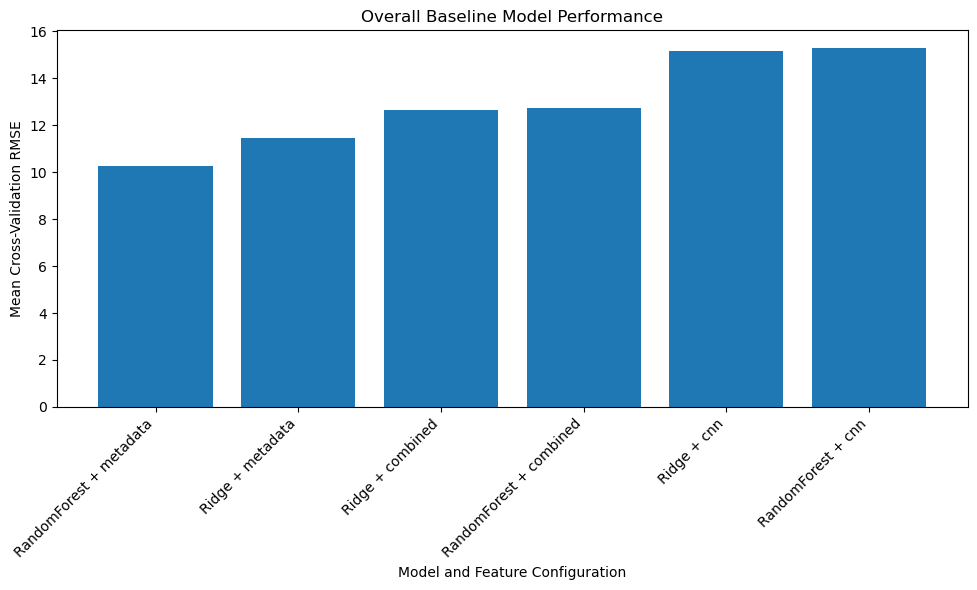

In [16]:
# ============================================================
# VISUALIZE OVERALL BASELINE PERFORMANCE
# ============================================================

plot_labels = (
    overall_model_ranking["model"]
    + " + "
    + overall_model_ranking["feature_set"]
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_labels,
    overall_model_ranking["Mean_RMSE"],
)

plt.xlabel("Model and Feature Configuration")
plt.ylabel("Mean Cross-Validation RMSE")
plt.title("Overall Baseline Model Performance")

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

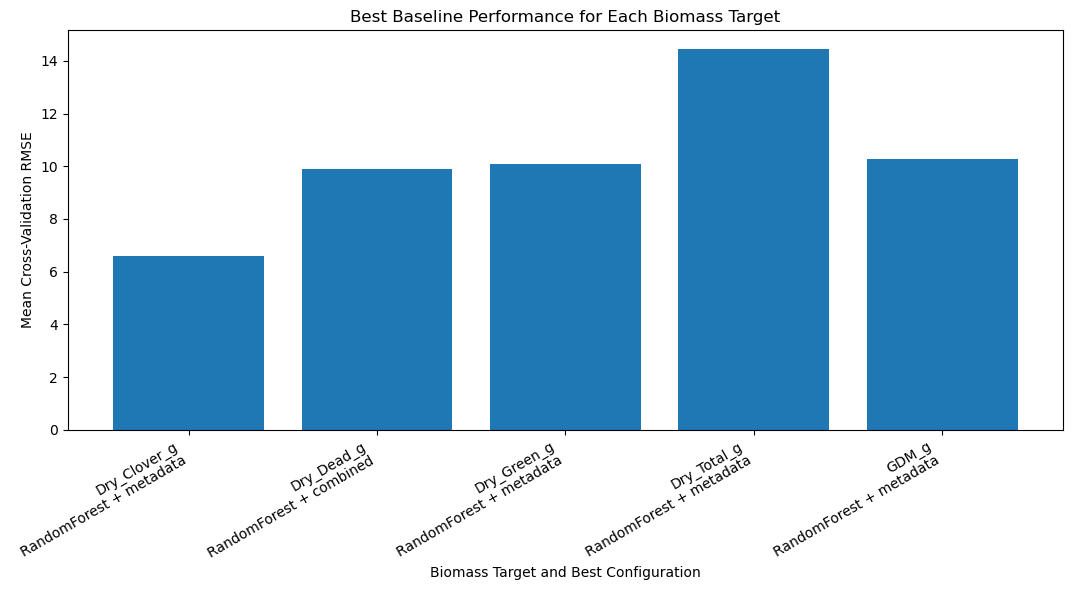

In [17]:
# ============================================================
# VISUALIZE BEST RMSE FOR EACH BIOMASS TARGET
# ============================================================

target_labels = (
    best_model_per_target["target"]
    + "\n"
    + best_model_per_target["model"]
    + " + "
    + best_model_per_target["feature_set"]
)

plt.figure(figsize=(11, 6))

plt.bar(
    target_labels,
    best_model_per_target["RMSE_mean"],
)

plt.xlabel("Biomass Target and Best Configuration")
plt.ylabel("Mean Cross-Validation RMSE")
plt.title("Best Baseline Performance for Each Biomass Target")

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# BUILD OOF PREDICTION TABLES
# ============================================================

all_oof_prediction_tables = []


for model_name, prediction_dictionary in [
    ("Ridge", ridge_oof_predictions),
    ("RandomForest", rf_oof_predictions),
]:

    for feature_set_name, predictions in prediction_dictionary.items():

        prediction_table = feature_table[
            [
                "image_path",
                "fold",
                *TARGET_COLUMNS,
            ]
        ].copy()

        prediction_table.insert(
            0,
            "feature_set",
            feature_set_name,
        )

        prediction_table.insert(
            0,
            "model",
            model_name,
        )

        for target_index, target_name in enumerate(TARGET_COLUMNS):

            prediction_table[
                f"pred_{target_name}"
            ] = predictions[:, target_index]

        all_oof_prediction_tables.append(
            prediction_table
        )


# ============================================================
# COMBINE OOF PREDICTION TABLES
# ============================================================

all_oof_predictions = pd.concat(
    all_oof_prediction_tables,
    ignore_index=True,
)


# ============================================================
# VALIDATE COMBINED OOF TABLE
# ============================================================

expected_oof_rows = (
    len(feature_table)
    * len(experiment_configurations)
)

if len(all_oof_predictions) != expected_oof_rows:
    raise ValueError(
        f"Expected {expected_oof_rows} OOF rows, "
        f"found {len(all_oof_predictions)}."
    )


print("=" * 60)
print("COMBINED OOF PREDICTION TABLE")
print("=" * 60)

print(f"Experiments : {len(experiment_configurations)}")
print(f"Samples     : {len(feature_table)}")
print(f"Total Rows  : {len(all_oof_predictions)}")
print(f"Columns     : {all_oof_predictions.shape[1]}")

print("=" * 60)

display(all_oof_predictions.head())

COMBINED OOF PREDICTION TABLE
Experiments : 6
Samples     : 357
Total Rows  : 2142
Columns     : 14


,model,feature_set,image_path,fold,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,pred_Dry_Clover_g,pred_Dry_Dead_g,pred_Dry_Green_g,pred_Dry_Total_g,pred_GDM_g
0,Ridge,cnn,train/ID1011485656.jpg,3,0.0000,31.9984,16.2751,48.2735,16.2750,-0.118818,20.137074,20.685291,40.702667,20.566422
1,Ridge,cnn,train/ID1012260530.jpg,4,0.0000,0.0000,7.6000,7.6000,7.6000,0.225771,-6.775556,16.469503,9.908968,16.695377
2,Ridge,cnn,train/ID1025234388.jpg,1,6.0500,0.0000,0.0000,6.0500,6.0500,-10.308458,-17.482327,-12.663797,-40.457481,-22.972023
3,Ridge,cnn,train/ID1028611175.jpg,3,0.0000,30.9703,24.2376,55.2079,24.2376,0.130929,33.081570,36.479454,69.713379,36.610271
4,Ridge,cnn,train/ID1035947949.jpg,0,0.4343,23.2239,10.5261,34.1844,10.9605,3.966226,23.597965,23.436344,51.000469,27.402565


In [19]:
# ============================================================
# SAVE BASELINE MODELING ARTIFACTS
# ============================================================

fold_metrics_path = (
    REPORTS_DIR
    / "baseline_fold_metrics.csv"
)

cv_summary_path = (
    REPORTS_DIR
    / "baseline_cv_summary.csv"
)

model_ranking_path = (
    REPORTS_DIR
    / "baseline_model_ranking.csv"
)

best_target_models_path = (
    REPORTS_DIR
    / "best_baseline_models_per_target.csv"
)

oof_predictions_path = (
    PREDICTIONS_DIR
    / "baseline_oof_predictions.csv"
)


# ============================================================
# SAVE ARTIFACTS
# ============================================================

all_fold_metrics.to_csv(
    fold_metrics_path,
    index=False,
)

all_cv_summary.to_csv(
    cv_summary_path,
    index=False,
)

overall_model_ranking.to_csv(
    model_ranking_path,
    index=False,
)

best_model_per_target.to_csv(
    best_target_models_path,
    index=False,
)

all_oof_predictions.to_csv(
    oof_predictions_path,
    index=False,
)


# ============================================================
# SAVE SUMMARY
# ============================================================

print("=" * 60)
print("BASELINE MODELING ARTIFACTS SAVED")
print("=" * 60)

print(f"Fold Metrics      : {fold_metrics_path}")
print(f"CV Summary        : {cv_summary_path}")
print(f"Model Ranking     : {model_ranking_path}")
print(f"Best Target Models: {best_target_models_path}")
print(f"OOF Predictions   : {oof_predictions_path}")

print("=" * 60)

BASELINE MODELING ARTIFACTS SAVED
Fold Metrics      : E:\DATAVIDWAN\Image2Biomass\outputs\reports\baseline_fold_metrics.csv
CV Summary        : E:\DATAVIDWAN\Image2Biomass\outputs\reports\baseline_cv_summary.csv
Model Ranking     : E:\DATAVIDWAN\Image2Biomass\outputs\reports\baseline_model_ranking.csv
Best Target Models: E:\DATAVIDWAN\Image2Biomass\outputs\reports\best_baseline_models_per_target.csv
OOF Predictions   : E:\DATAVIDWAN\Image2Biomass\outputs\predictions\baseline_oof_predictions.csv


In [20]:
# ============================================================
# FINAL BASELINE MODELING INTEGRITY VALIDATION
# ============================================================

required_artifact_paths = [
    fold_metrics_path,
    cv_summary_path,
    model_ranking_path,
    best_target_models_path,
    oof_predictions_path,
]

missing_artifacts = [
    path
    for path in required_artifact_paths
    if not path.exists()
]


# ============================================================
# STRUCTURAL VALIDATION
# ============================================================

expected_experiments = 6
expected_fold_metric_rows = 150
expected_summary_rows = 30
expected_oof_rows = 2142

validation_checks = {
    "experiments": (
        len(experiment_configurations)
        == expected_experiments
    ),
    "fold_metric_rows": (
        len(all_fold_metrics)
        == expected_fold_metric_rows
    ),
    "summary_rows": (
        len(all_cv_summary)
        == expected_summary_rows
    ),
    "oof_rows": (
        len(all_oof_predictions)
        == expected_oof_rows
    ),
    "missing_artifacts": (
        len(missing_artifacts) == 0
    ),
    "fold_metrics_finite": (
        np.isfinite(
            all_fold_metrics[
                ["MAE", "RMSE", "R2"]
            ].to_numpy()
        ).all()
    ),
    "cv_summary_finite": (
        np.isfinite(
            all_cv_summary[
                [
                    "MAE_mean",
                    "RMSE_mean",
                    "R2_mean",
                ]
            ].to_numpy()
        ).all()
    ),
}


# ============================================================
# FINAL OUTPUT
# ============================================================

print("=" * 60)
print("FINAL BASELINE MODELING INTEGRITY VALIDATION")
print("=" * 60)

print(f"Samples                 : {len(feature_table)}")
print(f"Targets                 : {len(TARGET_COLUMNS)}")
print(f"Cross-Validation Folds  : {feature_table['fold'].nunique()}")
print(f"Models                  : {all_fold_metrics['model'].nunique()}")
print(f"Feature Sets            : {all_fold_metrics['feature_set'].nunique()}")
print(f"Experiments             : {len(experiment_configurations)}")
print(f"Fold Metric Rows        : {len(all_fold_metrics)}")
print(f"CV Summary Rows         : {len(all_cv_summary)}")
print(f"OOF Prediction Rows     : {len(all_oof_predictions)}")
print(f"Saved Artifacts         : {len(required_artifact_paths)}")

print("\nValidation Checks:")

for check_name, check_result in validation_checks.items():
    print(
        f"{check_name:<25}: "
        f"{'PASSED' if check_result else 'FAILED'}"
    )

print("\nBest Overall Baseline:")

print(
    f"Model                   : "
    f"{best_experiment['model']}"
)

print(
    f"Feature Set             : "
    f"{best_experiment['feature_set']}"
)

print(
    f"Mean RMSE               : "
    f"{best_experiment['Mean_RMSE']:.4f}"
)

print(
    f"Mean R2                 : "
    f"{best_experiment['Mean_R2']:.4f}"
)

print("=" * 60)


# ============================================================
# RAISE ERROR IF ANY CHECK FAILED
# ============================================================

failed_checks = [
    check_name
    for check_name, check_result
    in validation_checks.items()
    if not check_result
]

if failed_checks:
    raise ValueError(
        f"Final integrity validation failed: {failed_checks}"
    )

print("Baseline modeling pipeline validation passed successfully.")

FINAL BASELINE MODELING INTEGRITY VALIDATION
Samples                 : 357
Targets                 : 5
Cross-Validation Folds  : 5
Models                  : 2
Feature Sets            : 3
Experiments             : 6
Fold Metric Rows        : 150
CV Summary Rows         : 30
OOF Prediction Rows     : 2142
Saved Artifacts         : 5

Validation Checks:
experiments              : PASSED
fold_metric_rows         : PASSED
summary_rows             : PASSED
oof_rows                 : PASSED
missing_artifacts        : PASSED
fold_metrics_finite      : PASSED
cv_summary_finite        : PASSED

Best Overall Baseline:
Model                   : RandomForest
Feature Set             : metadata
Mean RMSE               : 10.2828
Mean R2                 : 0.6815
Baseline modeling pipeline validation passed successfully.


# Conclusion

This notebook established reproducible baseline performance for the CSIRO Image2Biomass prediction task using the feature artifacts generated in Notebook 03.

## Experiments Completed

Two regression algorithms were evaluated:

- Ridge Regression
- Random Forest Regression

Each model was trained and evaluated using three feature configurations:

- CNN features
- Metadata features
- Combined CNN and metadata features

This resulted in a total of 6 experiments evaluated using the predefined 5-fold cross-validation strategy.

## Key Results

The best overall baseline configuration was:

- **Model:** Random Forest
- **Feature Set:** Metadata
- **Mean RMSE:** 10.2828
- **Mean R²:** 0.6815

Random Forest achieved the best target-specific performance for all five biomass targets.

The metadata-only Random Forest configuration achieved the best performance for four targets:

- Dry Clover Biomass
- Dry Green Biomass
- Total Dry Biomass
- Green Dry Matter

The combined CNN and metadata Random Forest configuration achieved the best performance for:

- Dry Dead Biomass

## Main Findings

The experiments demonstrate that the available pasture metadata contains strong predictive information for biomass estimation.

Metadata-only models substantially outperformed CNN-only models, indicating that the frozen EfficientNetB0 embeddings do not yet capture enough task-specific visual information to outperform structured field metadata.

Combining CNN and metadata features improved performance over CNN-only configurations but did not outperform the metadata-only Random Forest baseline overall.

These results establish an important benchmark for subsequent modeling stages. Future experiments should aim to improve the contribution of visual information through task-specific deep learning, fine-tuning, improved image representations, or multimodal fusion strategies.

## Generated Artifacts

The notebook generated and saved:

- Fold-level cross-validation metrics
- Aggregated cross-validation summaries
- Overall baseline model rankings
- Best model configurations for each biomass target
- Out-of-fold predictions for all baseline experiments

All generated artifacts passed structural and numerical integrity validation.

## Next Steps

The next modeling stage will build upon these baseline results by exploring more advanced approaches for biomass prediction and evaluating whether task-specific image learning can improve upon the established Random Forest metadata baseline.